# 05 — Screenshot Capture Tests (WSL2 / PowerShell)

On WSL2, `mss` cannot access the Windows display. This notebook uses
**PowerShell's `System.Drawing.Graphics.CopyFromScreen`** via `subprocess`
to capture the Windows primary screen and load it back into Python as a PIL Image.

| Step | What is tested |
|---|---|
| 1 | PowerShell availability |
| 2 | `capture_windows_screen` — single shot, load back as PIL |
| 3 | AoE2 window detection via `pygetwindow` |
| 4 | `capture_screenshot` (updated capture.py — PowerShell via subprocess) |
| 5 | `save_screenshot` — file written and readable |
| 6 | Perceptual hash computation (speed + correctness) |
| 7 | Hash dedup logic — same frame skips VLM, changed frame doesn't |
| 8 | Minimap crop heuristic |
| 9 | `CaptureLoop.run_once` — three consecutive calls, dedup in action |
| 10 | Timing benchmark |
| 11 | System diagnostics |

> **Read-only** — no game input is sent at any point.

In [1]:
import sys
sys.path.insert(0, "/mnt/e/Personal/Samarth/repository/AOE-Agent/src")

import os, time, pathlib, subprocess, glob
import imagehash
from PIL import Image
from IPython.display import display

from aoe2_agent.perception.capture import (
    capture_screenshot,
    save_screenshot,
    get_aoe2_window_bbox,
    CaptureLoop,
    _WSL_SCREENSHOTS,
)
from aoe2_agent.config import HASH_THRESHOLD

CAPTURE_OUT = str(_WSL_SCREENSHOTS)   # shared screenshots directory
os.makedirs(CAPTURE_OUT, exist_ok=True)

print("Imports OK")
print(f"Screenshots dir  : {CAPTURE_OUT}")
print(f"Hash threshold   : {HASH_THRESHOLD}")

Imports OK
Screenshots dir  : /mnt/e/Personal/Samarth/repository/AOE-Agent/images/screenshots
Hash threshold   : 8


## 1 — PowerShell Availability Check

In [2]:
result = subprocess.run(
    ["powershell.exe", "-Command", "$PSVersionTable.PSVersion.ToString()"],
    capture_output=True, text=True
)
if result.returncode == 0:
    print(f"powershell.exe   : OK  (v{result.stdout.strip()})")
else:
    print(f"powershell.exe   : ERROR — {result.stderr.strip()}")

# Check System.Drawing is accessible
r2 = subprocess.run(
    ["powershell.exe", "-Command",
     "[Reflection.Assembly]::LoadWithPartialName('System.Drawing') | Out-Null; "
     "Write-Output 'System.Drawing OK'"],
    capture_output=True, text=True
)
print(f"System.Drawing   : {r2.stdout.strip() or r2.stderr.strip()}")

r3 = subprocess.run(
    ["powershell.exe", "-Command",
     "[Reflection.Assembly]::LoadWithPartialName('System.Windows.Forms') | Out-Null; "
     "Write-Output 'System.Windows.Forms OK'"],
    capture_output=True, text=True
)
print(f"System.W.Forms   : {r3.stdout.strip() or r3.stderr.strip()}")

powershell.exe   : OK  (v5.1.26100.8749)
System.Drawing   : System.Drawing OK
System.W.Forms   : System.Windows.Forms OK


## 2 — `capture_windows_screen` — Single Shot

In [3]:
# Windows path where PowerShell saves the PNG
_WIN_SCREENSHOTS = r"E:\Personal\Samarth\repository\AOE-Agent\images\screenshots"

def capture_windows_screen(output_filename: str = "screenshot.png") -> Image.Image | None:
    """Capture the Windows primary screen via PowerShell and return a PIL Image.

    Uses System.Drawing.Graphics.CopyFromScreen — works from WSL2 because
    powershell.exe runs natively on Windows and writes to a path both sides share.

    Returns:
        PIL Image (RGB) on success, None on failure.
    """
    os.makedirs(CAPTURE_OUT, exist_ok=True)
    windows_path = f"{_WIN_SCREENSHOTS}\\{output_filename}"
    wsl_path = pathlib.Path(CAPTURE_OUT) / output_filename  # ← corrected WSL path

    powershell_cmd = (
        "[Reflection.Assembly]::LoadWithPartialName('System.Drawing') | Out-Null; "
        "[Reflection.Assembly]::LoadWithPartialName('System.Windows.Forms') | Out-Null; "
        "$bounds = [System.Windows.Forms.Screen]::PrimaryScreen.Bounds; "
        "$bmp = New-Object System.Drawing.Bitmap $bounds.Width, $bounds.Height; "
        "$graphics = [System.Drawing.Graphics]::FromImage($bmp); "
        "$graphics.CopyFromScreen($bounds.Location, [System.Drawing.Point]::Empty, $bounds.Size); "
        f"$bmp.Save('{windows_path}', [System.Drawing.Imaging.ImageFormat]::Png); "
        "$graphics.Dispose(); $bmp.Dispose();"
    )

    try:
        subprocess.run(
            ["powershell.exe", "-Command", powershell_cmd],
            check=True, capture_output=True,
        )
        img = Image.open(wsl_path).convert("RGB")
        print(f"Saved to WSL path : {wsl_path}")
        return img
    except subprocess.CalledProcessError as e:
        print(f"PowerShell failed : {e.stderr.decode(errors='replace')[:200]}")
        return None
    except Exception as e:
        print(f"Load failed       : {e}")
        return None

Saved to WSL path : /mnt/e/Personal/Samarth/repository/AOE-Agent/images/screenshots/test_shot.png
Size    : 1536×864 px
Mode    : RGB
Elapsed : 411 ms

Capture OK


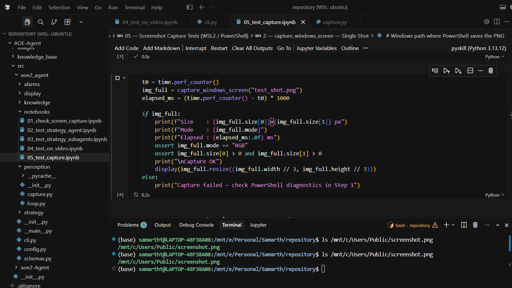

In [4]:
t0 = time.perf_counter()
img_full = capture_windows_screen("test_shot.png")
elapsed_ms = (time.perf_counter() - t0) * 1000

if img_full:
    print(f"Size    : {img_full.size[0]}×{img_full.size[1]} px")
    print(f"Mode    : {img_full.mode}")
    print(f"Elapsed : {elapsed_ms:.0f} ms")
    assert img_full.mode == "RGB"
    assert img_full.size[0] > 0 and img_full.size[1] > 0
    print("\nCapture OK")
    display(img_full.resize((img_full.width // 3, img_full.height // 3)))
else:
    print("Capture failed — check PowerShell diagnostics in Step 1")

## 3 — AoE2 Window Detection

In [5]:
bbox = get_aoe2_window_bbox()

if bbox:
    left, top, w, h = bbox
    print(f"AoE2 window FOUND : left={left}  top={top}  width={w}  height={h}")
else:
    print("AoE2 window NOT found — game is probably not running.")
    print("The PowerShell capture always takes the full primary screen.")
    print("When the game is running fullscreen, the full screen IS the game.")

AoE2 window NOT found — game is probably not running.
The PowerShell capture always takes the full primary screen.
When the game is running fullscreen, the full screen IS the game.


## 4 — `capture_screenshot` from updated `capture.py`

`capture.py` now uses PowerShell via subprocess.

capture_screenshot() → 1536×864 px  mode=RGB  453 ms
capture_screenshot OK


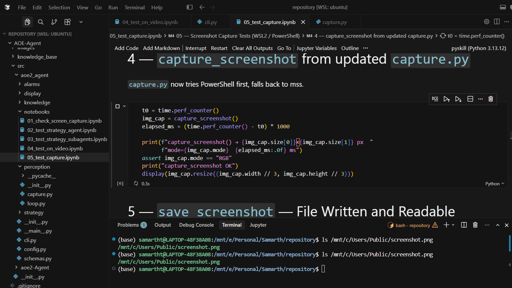

In [6]:
t0 = time.perf_counter()
img_cap = capture_screenshot()
elapsed_ms = (time.perf_counter() - t0) * 1000

print(f"capture_screenshot() → {img_cap.size[0]}×{img_cap.size[1]} px  "
      f"mode={img_cap.mode}  {elapsed_ms:.0f} ms")
assert img_cap.mode == "RGB"
print("capture_screenshot OK")
display(img_cap.resize((img_cap.width // 3, img_cap.height // 3)))

## 5 — `save_screenshot` — File Written and Readable

In [ ]:
saved_path = save_screenshot(img_cap, out_dir=CAPTURE_OUT)

assert pathlib.Path(saved_path).exists(), f"File not found: {saved_path}"
size_kb = pathlib.Path(saved_path).stat().st_size / 1024

reloaded = Image.open(saved_path)
assert reloaded.size == img_cap.size, "Round-trip size mismatch"

print(f"Saved to   : {saved_path}")
print(f"File size  : {size_kb:.1f} KB")
print(f"Dimensions : {reloaded.size[0]}×{reloaded.size[1]} px")
print("save_screenshot round-trip OK")

## 6 — Perceptual Hash Computation

In [ ]:
def phash(img):
    return imagehash.average_hash(img.resize((64, 64)).convert("L"))

t0 = time.perf_counter()
h1 = phash(img_cap)
hash_ms = (time.perf_counter() - t0) * 1000

print(f"Hash value       : {h1}")
print(f"Elapsed          : {hash_ms:.2f} ms")

# Same image → diff == 0
assert (h1 - phash(img_cap)) == 0, "Same image should produce diff=0"
print("Same image diff  : 0  ✓")

# All-black image → diff > 0
black = Image.new("RGB", img_cap.size, (0, 0, 0))
diff_black = h1 - phash(black)
print(f"vs all-black     : {diff_black}  {'✓' if diff_black > 0 else '✗'}  (expect > 0)")

## 7 — Hash Dedup Logic

In [ ]:
# Scenario A: identical image → skip VLM
h_a = phash(img_cap)
diff_same = h_a - phash(img_cap)
print(f"Identical frame  diff={diff_same:2d}  needs_vlm={diff_same > HASH_THRESHOLD}  "
      f"({'✓ skip VLM' if diff_same <= HASH_THRESHOLD else '✗'})")

# Scenario B: all-white image → call VLM
white = Image.new("RGB", img_cap.size, (255, 255, 255))
diff_white = h_a - phash(white)
print(f"All-white frame  diff={diff_white:2d}  needs_vlm={diff_white > HASH_THRESHOLD}  "
      f"({'✓ call VLM' if diff_white > HASH_THRESHOLD else '✗'})")

# Scenario C: two live captures ~1s apart
img_x = capture_windows_screen("dedup_x.png")
time.sleep(1.0)
img_y = capture_windows_screen("dedup_y.png")
if img_x and img_y:
    diff_live = phash(img_x) - phash(img_y)
    print(f"Live 1s apart    diff={diff_live:2d}  needs_vlm={diff_live > HASH_THRESHOLD}  "
          f"(0 = nothing moved, >threshold = screen changed)")

## 8 — Minimap Crop Heuristic

In [ ]:
loop_obj = CaptureLoop(out_dir=CAPTURE_OUT, hash_threshold=HASH_THRESHOLD)
W, H = img_cap.size
minimap = loop_obj._crop_minimap(img_cap)

expected_w = int(W * 0.18)
expected_h = int(H * 0.18)

print(f"Full frame   : {W}×{H}")
print(f"Minimap crop : {minimap.size[0]}×{minimap.size[1]}")
print(f"Expected     : ~{expected_w}×{expected_h}  (bottom-right 18%)")

assert minimap.size == (expected_w, expected_h), "Minimap dimensions wrong"
print("Minimap crop OK — bottom-right of screen:")
display(minimap)

## 9 — `CaptureLoop.run_once` — Three Consecutive Calls

In [7]:
loop = CaptureLoop(out_dir=CAPTURE_OUT, interval=1.0, hash_threshold=HASH_THRESHOLD)

results = []
for i in range(3):
    t0 = time.perf_counter()
    path, img, needs_vlm = loop.run_once()
    elapsed = (time.perf_counter() - t0) * 1000
    results.append((path, img, needs_vlm, elapsed))
    label = "CALL VLM" if needs_vlm else "skip VLM"
    print(f"  Call {i+1}:  {label:<10}  "
          f"{img.size[0]}×{img.size[1]}  "
          f"{elapsed:.0f} ms  →  {pathlib.Path(path).name}")

assert results[0][2] == True, "First capture must always trigger VLM"
print("\n✓ First call always triggers VLM (no prior hash)")
print(f"  Calls 2-3 dedup: {['no change' if not r[2] else 'changed' for r in results[1:]]}")

  Call 1:  CALL VLM    1536×864  573 ms  →  screenshot_1782751234093.png
  Call 2:  skip VLM    1536×864  492 ms  →  screenshot_1782751234593.png
  Call 3:  skip VLM    1536×864  520 ms  →  screenshot_1782751235113.png

✓ First call always triggers VLM (no prior hash)
  Calls 2-3 dedup: ['no change', 'no change']


## 10 — Timing Benchmark

In [9]:
print("=== System Diagnostics ===")
print()

# PowerShell version
r = subprocess.run(
    ["powershell.exe", "-Command", "$PSVersionTable.PSVersion.ToString()"],
    capture_output=True, text=True,
)
status = f"OK  (v{r.stdout.strip()})" if r.returncode == 0 else f"ERROR — {r.stderr.strip()}"
print(f"powershell.exe  : {status}")

# System.Drawing
r2 = subprocess.run(
    ["powershell.exe", "-Command",
     "[Reflection.Assembly]::LoadWithPartialName('System.Drawing') | Out-Null; "
     "Write-Output 'OK'"],
    capture_output=True, text=True,
)
print(f"System.Drawing  : {'OK' if r2.returncode == 0 else r2.stderr.strip()}")

# System.Windows.Forms
r3 = subprocess.run(
    ["powershell.exe", "-Command",
     "[Reflection.Assembly]::LoadWithPartialName('System.Windows.Forms') | Out-Null; "
     "Write-Output 'OK'"],
    capture_output=True, text=True,
)
print(f"System.W.Forms  : {'OK' if r3.returncode == 0 else r3.stderr.strip()}")

# Pillow
from PIL import __version__ as pv
print(f"Pillow          : OK  (v{pv})")

# imagehash
import imagehash as _ih
print(f"imagehash       : OK  (v{_ih.__version__})")

# pygetwindow
try:
    import pygetwindow as gw
    aoe = [w for w in gw.getAllWindows() if "Age" in w.title or "AoE" in w.title]
    print(f"pygetwindow     : OK  — {len(gw.getAllWindows())} windows, "
          f"{len(aoe)} AoE2 window(s)")
    for w in aoe:
        print(f"                  -> {w.title!r}  {w.width}x{w.height}")
except Exception as e:
    print(f"pygetwindow     : {e}")

# Screenshots on disk
screenshots = sorted(pathlib.Path(CAPTURE_OUT).glob("*.png"))
total_kb = sum(p.stat().st_size for p in screenshots) / 1024
print(f"\nScreenshots dir : {CAPTURE_OUT}")
print(f"Files saved     : {len(screenshots)} ({total_kb:.0f} KB total)")
for p in screenshots[-5:]:
    print(f"  {p.name!s:<42}  {p.stat().st_size / 1024:.0f} KB")


Saved to WSL path : /mnt/e/Personal/Samarth/repository/AOE-Agent/images/screenshots/bench_0.png
  Shot 1: 496 ms
Saved to WSL path : /mnt/e/Personal/Samarth/repository/AOE-Agent/images/screenshots/bench_1.png
  Shot 2: 475 ms
Saved to WSL path : /mnt/e/Personal/Samarth/repository/AOE-Agent/images/screenshots/bench_2.png
  Shot 3: 443 ms
Saved to WSL path : /mnt/e/Personal/Samarth/repository/AOE-Agent/images/screenshots/bench_3.png
  Shot 4: 426 ms
Saved to WSL path : /mnt/e/Personal/Samarth/repository/AOE-Agent/images/screenshots/bench_4.png
  Shot 5: 450 ms

Average  : 458 ms
Min/Max  : 426 / 496 ms
Captures/sec : 2.2

Perception loop interval : 3000 ms
Capture headroom         : 85% of budget
✓ Fast enough for the perception loop


## 11 — System Diagnostics

In [8]:
print("=== System Diagnostics ===")
print()

# PowerShell version
r = subprocess.run(
    ["powershell.exe", "-Command", "$PSVersionTable.PSVersion.ToString()"],
    capture_output=True, text=True,
)
status = f"OK  (v{r.stdout.strip()})" if r.returncode == 0 else f"ERROR — {r.stderr.strip()}"
print(f"powershell.exe  : {status}")

# System.Drawing
r2 = subprocess.run(
    ["powershell.exe", "-Command",
     "[Reflection.Assembly]::LoadWithPartialName('System.Drawing') | Out-Null; "
     "Write-Output 'OK'"],
    capture_output=True, text=True,
)
print(f"System.Drawing  : {'OK' if r2.returncode == 0 else r2.stderr.strip()}")

# System.Windows.Forms
r3 = subprocess.run(
    ["powershell.exe", "-Command",
     "[Reflection.Assembly]::LoadWithPartialName('System.Windows.Forms') | Out-Null; "
     "Write-Output 'OK'"],
    capture_output=True, text=True,
)
print(f"System.W.Forms  : {'OK' if r3.returncode == 0 else r3.stderr.strip()}")

# Pillow
from PIL import __version__ as pv
print(f"Pillow          : OK  (v{pv})")

# imagehash
import imagehash as _ih
print(f"imagehash       : OK  (v{_ih.__version__})")

# pygetwindow
try:
    import pygetwindow as gw
    aoe = [w for w in gw.getAllWindows() if "Age" in w.title or "AoE" in w.title]
    print(f"pygetwindow     : OK  — {len(gw.getAllWindows())} windows, "
          f"{len(aoe)} AoE2 window(s)")
    for w in aoe:
        print(f"                  -> {w.title!r}  {w.width}x{w.height}")
except Exception as e:
    print(f"pygetwindow     : {e}")

# Screenshots on disk
screenshots = sorted(pathlib.Path(CAPTURE_OUT).glob("*.png"))
total_kb = sum(p.stat().st_size for p in screenshots) / 1024
print(f"\nScreenshots dir : {CAPTURE_OUT}")
print(f"Files saved     : {len(screenshots)} ({total_kb:.0f} KB total)")
for p in screenshots[-5:]:
    print(f"  {p.name!s:<42}  {p.stat().st_size / 1024:.0f} KB")


=== System Diagnostics ===

powershell.exe : OK  (v5.1.26100.8749)
Screenshots    : 0 files  (0 KB total)
               : /mnt/e/Personal/Samarth/repository/AOE-Agent/images/screenshots
Pillow         : OK  (v12.1.1)
imagehash      : OK  (v4.3.2)
pygetwindow    : PyGetWindow currently does not support Linux. If you have Xlib knowledge, please contribute! https://github.com/asweigart/pygetwindow
mss (fallback) : OK  (v10.2.0)

All screenshots saved to:
